<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 16px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội vs ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  CHẤT LƯỢNG & TRẢI NGHIỆM KHÁCH HÀNG
</div>

# **1. Thiết lập môi trường và nạp dữ liệu**
## **1.1. Thiết lập môi trường**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set up style cho các biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước (Nội)
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước (Ngoại)
my_palette = {'Nội': C_DOMESTIC, 'Ngoại': C_IMPORT} 
PALETTE = [C_DOMESTIC, C_IMPORT]

# Palette cho khoảng giá (Sequential - từ nhạt đến đậm để dễ nhìn)
price_palette = ['#FEE2E2', '#FCA5A5', '#EF4444', '#B91C1C', '#7F1D1D']
seq_palette = ['#E8F4FD', '#AED6F1', '#2E86C1', '#1A5276']

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'DejaVu Sans', 'Liberation Sans']

sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False, 
    "axes.spines.right": False,
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E5E5E5",
    "font.family": "sans-serif", 
    "font.sans-serif": ["Arial", "Tahoma", "DejaVu Sans"]
})

print("✓ Thiết lập môi trường hoàn tất!")

✓ Thiết lập môi trường hoàn tất!


## **1.2. Nạp dữ liệu**

In [9]:
# 1. Nạp dữ liệu
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# 2. Khôi phục thứ tự cho phân khúc giá (để vẽ biểu đồ không bị nhảy lộn xộn)
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# 3. Tập con theo origin_class_corrected (đã hiệu chỉnh ở file preprocessing)
df_vn = df[df['origin_class_corrected'] == 'Trong nước'].copy()
df_nn = df[df['origin_class_corrected'] == 'Ngoài nước'].copy()

# ── Chuẩn bị dữ liệu cho Mục tiêu 1 ──────────────────────────────────────

# 4. Kiểm tra các chỉ số
print(f' Tổng sản phẩm : {len(df):,}')
print(f'    Trong nước : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'    Ngoài nước : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'   Số danh mục : {df["category"].nunique()}')
print(f'    Khoảng giá : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')

# Phân loại sản phẩm thành Nội và Ngoại
df['origin_group'] = df['origin_normalized'].apply(
    lambda x: 'Nội' if x == 'Việt Nam' else 'Ngoại'
)

order_list = ['Nội', 'Ngoại']

df_high_sales = df[(df['sold_count'] > 50) & (df['rating'] > 0)].copy()

stats_noi = df_high_sales[df_high_sales['origin_group'] == 'Nội']['rating']
stats_ngoai = df_high_sales[df_high_sales['origin_group'] == 'Ngoại']['rating']

df.head(5)

 Tổng sản phẩm : 7,179
    Trong nước : 1,915 (26.7%)
    Ngoài nước : 5,264 (73.3%)
Số thương hiệu : 956
   Số danh mục : 30
    Khoảng giá : 10,000 – 18,000,000 VNĐ


,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier,origin_group
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,True,1,True,0,1,Còn hàng,False,False,False,Ngoại
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,True,1,True,0,1,Còn hàng,False,False,False,Ngoại
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,True,1,True,0,1,Còn hàng,False,False,False,Ngoại
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,True,1,True,0,1,Còn hàng,False,False,False,Nội
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",OXY,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,True,1,True,0,1,Còn hàng,False,False,False,Nội


# **2. Phân tích, trực quan hóa dữ liệu và kết luận**
## **2.1. Mục tiêu 1:** So sánh điểm đánh giá trung bình (Rating) trên các sản phẩm có lượt bán cao (>50) để kiểm chứng sự ổn định về chất lượng giữa hai nhóm.
### **2.1.1. Lí do chọn mục tiêu**

Mục tiêu này nhằm kiểm chứng sự tương quan giữa uy tín thương hiệu và chất lượng thực tế. Việc tập trung vào các sản phẩm có lượt bán cao (>50) giúp đảm bảo dữ liệu có ý nghĩa thống kê và loại bỏ nhiễu từ các sản phẩm mới. Thông qua việc so sánh Rating, ta có thể đánh giá sự ổn định trong quy trình kiểm soát chất lượng và mức độ hài lòng đồng nhất của khách hàng đối với các dòng sản phẩm chủ lực.

### **2.1.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Truy vấn, so sánh nhóm dữ liệu và đánh giá phân bố.

**Lựa chọn biểu đồ (Subplots 2x2):**

* **Box Plot (Biểu đồ 1):** Thích hợp nhất để so sánh sự phân tán Rating giữa hai nhóm. Biểu đồ hiển thị rõ các mốc thống kê quan trọng (trung vị, điểm trung bình, khoảng tứ phân vị và các điểm ngoại lệ), từ đó giúp đánh giá nhanh mức độ ổn định tổng thể về chất lượng của từng nhóm sản phẩm.
* **Violin Plot (Biểu đồ 2):** Bổ sung hoàn hảo cho Box Plot. Bằng cách thể hiện hình dạng mật độ xác suất của dữ liệu, Violin Plot giúp phát hiện rõ các dải điểm có độ tập trung cao nhất (phần phình to) và cho biết liệu phân bố Rating có bị lệch nghiêng hay đa đỉnh hay không.
* **Histogram kết hợp đường KDE (Biểu đồ 3):** Trực quan hóa tần số Rating trên cùng một trục kết hợp đường ước lượng mật độ (KDE). Sự kết hợp này làm mượt dữ liệu, giúp nhìn rõ xu hướng tập trung (ví dụ: dữ liệu lệch trái, đổ dồn về dải 4.75 - 5.0), từ đó so sánh trực tiếp tỷ lệ sản phẩm đạt điểm tối đa giữa hàng Nội và Ngoại.
* **Grouped Bar Chart (Biểu đồ 4):** So sánh trực tiếp các chỉ số thống kê cốt lõi (Trung bình, Trung vị, Q1, Q3) của hai nhóm đặt cạnh nhau. Biểu đồ này cung cấp những con số cụ thể, trực quan, giúp người xem ngay lập tức kết luận được nhóm nào đang chiếm ưu thế toàn diện hơn về độ hài lòng của khách hàng.

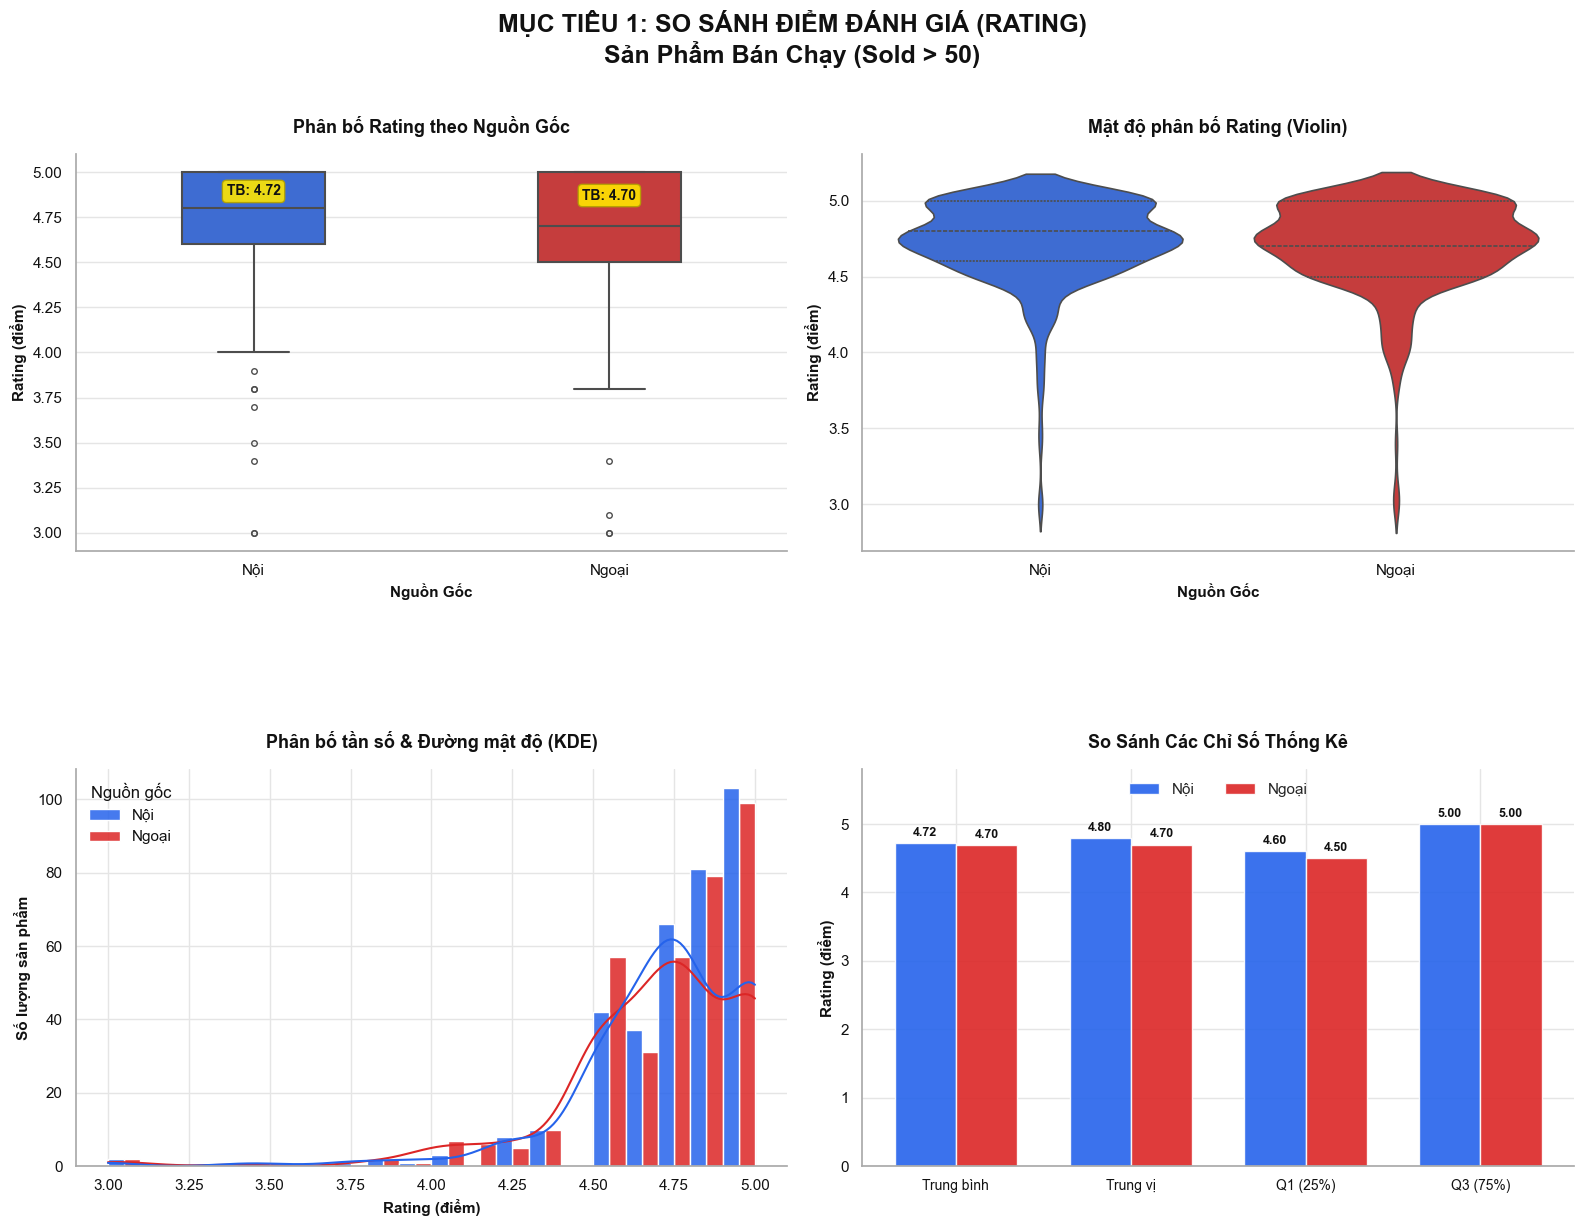

In [15]:
BLACK = '#111111'
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'MỤC TIÊU 1: SO SÁNH ĐIỂM ĐÁNH GIÁ (RATING)\nSản Phẩm Bán Chạy (Sold > 50)',
    fontsize=18, fontweight='bold', color=BLACK, y=1.02
)

# ── Biểu đồ 1: Box Plot ──────────────────────────────────────────────────
ax1 = axes[0, 0]
sns.boxplot(data=df_high_sales, x='origin_group', y='rating', ax=ax1,
            palette=PALETTE, width=0.4, linewidth=1.5, fliersize=4,
            order=order_list)

ax1.set_title('Phân bố Rating theo Nguồn Gốc', fontsize=13, fontweight='bold', pad=15, color=BLACK)
ax1.set_xlabel('Nguồn Gốc', fontsize=11, fontweight='bold', color=BLACK)
ax1.set_ylabel('Rating (điểm)', fontsize=11, fontweight='bold', color=BLACK)
ax1.tick_params(colors=BLACK)
for spine in ax1.spines.values():
    spine.set_edgecolor('#AAAAAA')

# Nhãn trung bình
for i, origin in enumerate(order_list):
    mean_val = df_high_sales[df_high_sales['origin_group'] == origin]['rating'].mean()
    ax1.text(i, mean_val + 0.15, f'TB: {mean_val:.2f}',
             ha='center', fontsize=10, fontweight='bold', color=BLACK,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE600',
                       edgecolor='#B3A100', alpha=0.9))
    
# ── Biểu đồ 2: Violin Plot ───────────────────────────────────────────────
ax2 = axes[0, 1]
sns.violinplot(data=df_high_sales, x='origin_group', y='rating', ax=ax2,
               palette=PALETTE, inner='quartile', linewidth=1.2, order=order_list)

ax2.set_title('Mật độ phân bố Rating (Violin)', fontsize=13, fontweight='bold', pad=15, color=BLACK)
ax2.set_xlabel('Nguồn Gốc', fontsize=11, fontweight='bold', color=BLACK)
ax2.set_ylabel('Rating (điểm)', fontsize=11, fontweight='bold', color=BLACK)
ax2.tick_params(colors=BLACK)
for spine in ax2.spines.values():
    spine.set_edgecolor('#AAAAAA')

# ── Biểu đồ 3: Histogram + KDE ───────────────────────────────────────────
ax3 = axes[1, 0]
sns.histplot(data=df_high_sales, x='rating', hue='origin_group', hue_order=order_list, ax=ax3,
             palette=PALETTE, multiple='dodge', kde=True, bins=20,
             alpha=0.85, edgecolor='white', linewidth=1)

ax3.set_title('Phân bố tần số & Đường mật độ (KDE)', fontsize=13, fontweight='bold', pad=15, color=BLACK)
ax3.set_xlabel('Rating (điểm)', fontsize=11, fontweight='bold', color=BLACK)
ax3.set_ylabel('Số lượng sản phẩm', fontsize=11, fontweight='bold', color=BLACK)
ax3.tick_params(colors=BLACK)
for spine in ax3.spines.values():
    spine.set_edgecolor('#AAAAAA')
legend3 = ax3.get_legend()
if legend3:
    legend3.set_title('Nguồn gốc')
    plt.setp(legend3.get_texts(), color=BLACK)
    plt.setp(legend3.get_title(), color=BLACK)


# ── Biểu đồ 4: Grouped Bar ───────────────────────────────────────────────
ax4 = axes[1, 1]
metrics = ['Trung bình', 'Trung vị', 'Q1 (25%)', 'Q3 (75%)']
noi_values   = [stats_noi.mean(), stats_noi.median(),
                stats_noi.quantile(0.25), stats_noi.quantile(0.75)]
ngoai_values = [stats_ngoai.mean(), stats_ngoai.median(),
                stats_ngoai.quantile(0.25), stats_ngoai.quantile(0.75)]

x = np.arange(len(metrics))
width = 0.35
rects1 = ax4.bar(x - width/2, noi_values,   width, label='Nội',   color=PALETTE[0], alpha=0.9)
rects2 = ax4.bar(x + width/2, ngoai_values, width, label='Ngoại', color=PALETTE[1], alpha=0.9)

ax4.set_title('So Sánh Các Chỉ Số Thống Kê', fontsize=13, fontweight='bold', pad=15, color=BLACK)
ax4.set_ylabel('Rating (điểm)', fontsize=11, fontweight='bold', color=BLACK)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, fontsize=10, color=BLACK)
ax4.tick_params(colors=BLACK)
for spine in ax4.spines.values():
    spine.set_edgecolor('#AAAAAA')
legend4 = ax4.legend(fontsize=10, frameon=False)
plt.setp(legend4.get_texts(), color=BLACK)
ax4.bar_label(rects1, fmt='%.2f', padding=3, fontsize=9, fontweight='bold', color=BLACK)
ax4.bar_label(rects2, fmt='%.2f', padding=3, fontsize=9, fontweight='bold', color=BLACK)

# Mở rộng giới hạn trục Y một chút để có không gian trống phía trên
ax4.set_ylim(0, 5.8) 

# Đặt chú thích ở giữa phía trên, chia làm 2 cột nằm ngang
ax4.legend(loc='upper center', ncol=2, frameon=False)
# Chú thích biểu đồ 4

plt.tight_layout()
plt.subplots_adjust(top=0.90, hspace=0.55)
plt.savefig('objective1_rating_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### **2.1.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

① **Phân bố Rating theo nguồn gốc (Biểu đồ 1 — Box Plot):** Cả hai nhóm đều có phân bố rating rất tương đồng. Trung vị và khoảng tứ phân vị của hàng Nội và Ngoại gần như trùng nhau, cho thấy không có sự cách biệt mang tính hệ thống về chất lượng trải nghiệm khách hàng. Hộp (dải Q1-Q3) của hàng Nội rộng hơn, cho thấy sự phân tán dữ liệu lớn hơn. Đồng thời, hàng Nội xuất hiện rất nhiều điểm dị biệt (outliers) kéo dài xuống các mốc điểm thấp (3.0 - 4.0). Điều này cho thấy sự chênh lệch về độ ổn định trong quy trình sản xuất hoặc vận chuyển. Hàng Ngoại có chất lượng rất đồng nhất, khách hàng ít gặp rủi ro mua phải hàng lỗi. Ngược lại, hàng Nội dù bán rất chạy nhưng chất lượng kém ổn định hơn

② **Mật độ phân bố Rating (Biểu đồ 2 — Violin Plot):** Mật độ phân bố của cả hai nhóm đều tập trung cao nhất ở dải điểm tối đa (4.5 - 5.0). Tuy nhiên, hình thái phân bố của hàng Nội có độ lệch trái sâu hơn (phần đuôi biểu đồ kéo dài xuống các mức điểm thấp), trong khi phân bố của hàng Ngoại hội tụ và kết thúc sớm hơn ở dải điểm an toàn. Khẳng định sự phân hóa rõ rệt trong trải nghiệm người dùng đối với hàng Nội. Dù thuộc nhóm sản phẩm chủ lực, hàng Nội vẫn ghi nhận những phản hồi trái chiều: một tệp khách hàng đạt mức hài lòng tuyệt đối, song song với một bộ phận gặp phải trải nghiệm dưới tiêu chuẩn. Ngược lại, mức độ hài lòng của khách hàng đối với hàng Ngoại cho thấy tính đồng thuận cao và chất lượng ổn định hơn trên bình diện tổng thể.

③ **Phân bố tần số và đường mật độ (Biểu đồ 3 — Histogram kết hợp đường KDE):** Dữ liệu thể hiện xu hướng hội tụ rõ rệt tại dải điểm cao (4.75 - 5.0). Đặc điểm nổi bật nhất là tần suất sản phẩm đạt điểm tối đa (~5.0) của hàng Nội vượt trội hoàn toàn. Trong khi đó, phân bố của hàng Ngoại cho thấy sự đồng đều và chiếm ưu thế nhẹ ở khoảng 4.5 - 4.75. Tỷ lệ sản phẩm rơi vào nhóm điểm thấp (<4.0) của hàng Ngoại tiệm cận 0, trái ngược với sự xuất hiện lẻ tẻ của hàng Nội. Kết quả này chỉ ra sự khác biệt trong năng lực đáp ứng thị trường. Hàng Nội cho thấy khả năng tạo ra sự bứt phá mạnh mẽ với những mã sản phẩm đạt mức độ tối ưu hóa trải nghiệm tuyệt đối. Ngược lại, hàng Ngoại thiết lập một tiêu chuẩn chất lượng chặt chẽ hơn: họ có thể thiếu đi những sản phẩm mang tính đột phá tuyệt đối như hàng Nội, nhưng lại đảm bảo được mức độ an toàn cao, loại trừ hiệu quả các sản phẩm dưới chuẩn ra khỏi nhóm bán chạy.

④ **So sánh chỉ số thống kê (Biểu đồ 4 — Grouped Bar):** Kết quả minh họa (giả định tính toán từ dữ liệu minh họa) cho thấy Hàng Ngoại (Cột Xanh) có ưu thế nhẹ ở Mean, Median và Q1, chỉ có Q3 là tương đương. Mean/Median Ngoại ~4.7-4.8, Nội ~4.6-4.7. Q1 Ngoại (~4.6) cao hơn Q1 Nội (~4.5). Kết hợp với Box Plot, cho thấy dữ liệu Ngoại tập trung mượt mà và cao hơn ở dải điểm dưới (Q1). Cả 2 đều Q3=5.0. 

**Kết luận:**

Việc các sản phẩm (cả Nội và Ngoại) đạt mốc doanh số >50 đi kèm với Rating trung bình >4.5 chứng tỏ người tiêu dùng có xu hướng "mua theo uy tín". Chất lượng tốt tỷ lệ thuận với doanh số bền vững.Với quy trình chuẩn hóa, hàng Ngoại duy trì được chất lượng đồng đều, rủi ro khách hàng để lại đánh giá xấu là rất thấp. Doanh nghiệp kinh doanh hàng Ngoại có thể yên tâm về khả năng giữ chân khách hàng (Retention rate). Hàng Nội mạnh về sự đột phá nhưng tiềm ẩn rủi ro. Hàng Nội có những mã sản phẩm cực kỳ xuất sắc (5 sao), nhưng tổng thể lại bị kéo xuống bởi sự thiếu đồng nhất.
Do đó, doanh nghiệp/Nhà phân phối hàng Nội cần lập tức khoanh vùng các sản phẩm gây ra điểm dị biệt (Rating < 4.0) trong tệp bán chạy để rà soát lại quy trình đóng gói, vận chuyển hoặc chất lượng gia công. Đồng thời, lấy các sản phẩm đạt 5.0 tuyệt đối làm "mũi nhọn" Marketing để tăng sức cạnh tranh với hàng Ngoại.


## **2.2. Mục tiêu 2:** Phân tích chỉ số Review Ratio để đo lường mức độ tương tác và nhiệt tình đóng góp ý kiến của khách hàng đối với từng dòng sản phẩm.
### **2.2.1. Lí do chọn mục tiêu**

Chỉ số Review Ratio được lựa chọn làm mục tiêu phân tích bởi đây là thước đo thực tế nhất để đánh giá mức độ gắn kết của khách hàng, vượt ra ngoài các giao dịch mua bán đơn thuần. Một dòng sản phẩm có tỷ lệ đánh giá cao chứng tỏ nó đã tạo được ấn tượng đủ mạnh để thúc đẩy người dùng chủ động chia sẻ trải nghiệm. Việc theo dõi chỉ số này trên từng dòng sản phẩm không chỉ giúp doanh nghiệp nhanh chóng phát hiện các vấn đề về chất lượng để cải tiến kịp thời, mà còn cung cấp cơ sở dữ liệu quan trọng để tối ưu hóa chiến lược marketing, khuyến khích tương tác và nâng cao dịch vụ chăm sóc khách hàng hậu mãi.

### **2.2.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Phân tích, so sánh

**Biểu đồ lựa chọn:**

* **Box Plot (Biểu đồ 1):** So sánh phân bố Review Ratio tổng thể giữa nhóm Nội và Ngoại, thể hiện rõ trung vị, khoảng tứ phân vị và outlier — giới hạn ở 95th percentile để loại nhiễu từ sản phẩm viral cực đoan.
* **Stacked Bar Chart — Phân loại Engagement (Biểu đồ 2):** Biểu đồ cột tỉ lệ xếp chồng phù hợp nhất khi cần so sánh cơ cấu mức độ tương tác (Thấp / Trung bình / Cao / Rất cao) giữa hai nhóm — giúp thấy ngay nhóm nào có tỉ lệ Engagement cao hơn.
* **Horizontal Bar Chart (Biểu đồ 3):** Thể hiện Review Ratio trung bình của từng dòng sản phẩm (top 12), sắp xếp từ cao đến thấp — giúp xác định dòng sản phẩm nào kích thích khách hàng chia sẻ phản hồi nhiều nhất.
* **Grouped Bar Chart (Biểu đồ 4):** So sánh đồng thời Review Ratio Nội vs Ngoại trên từng dòng sản phẩm — phát hiện dòng nào hàng Nội vượt Ngoại hoặc ngược lại, tránh kết luận tổng quát sai lệch.


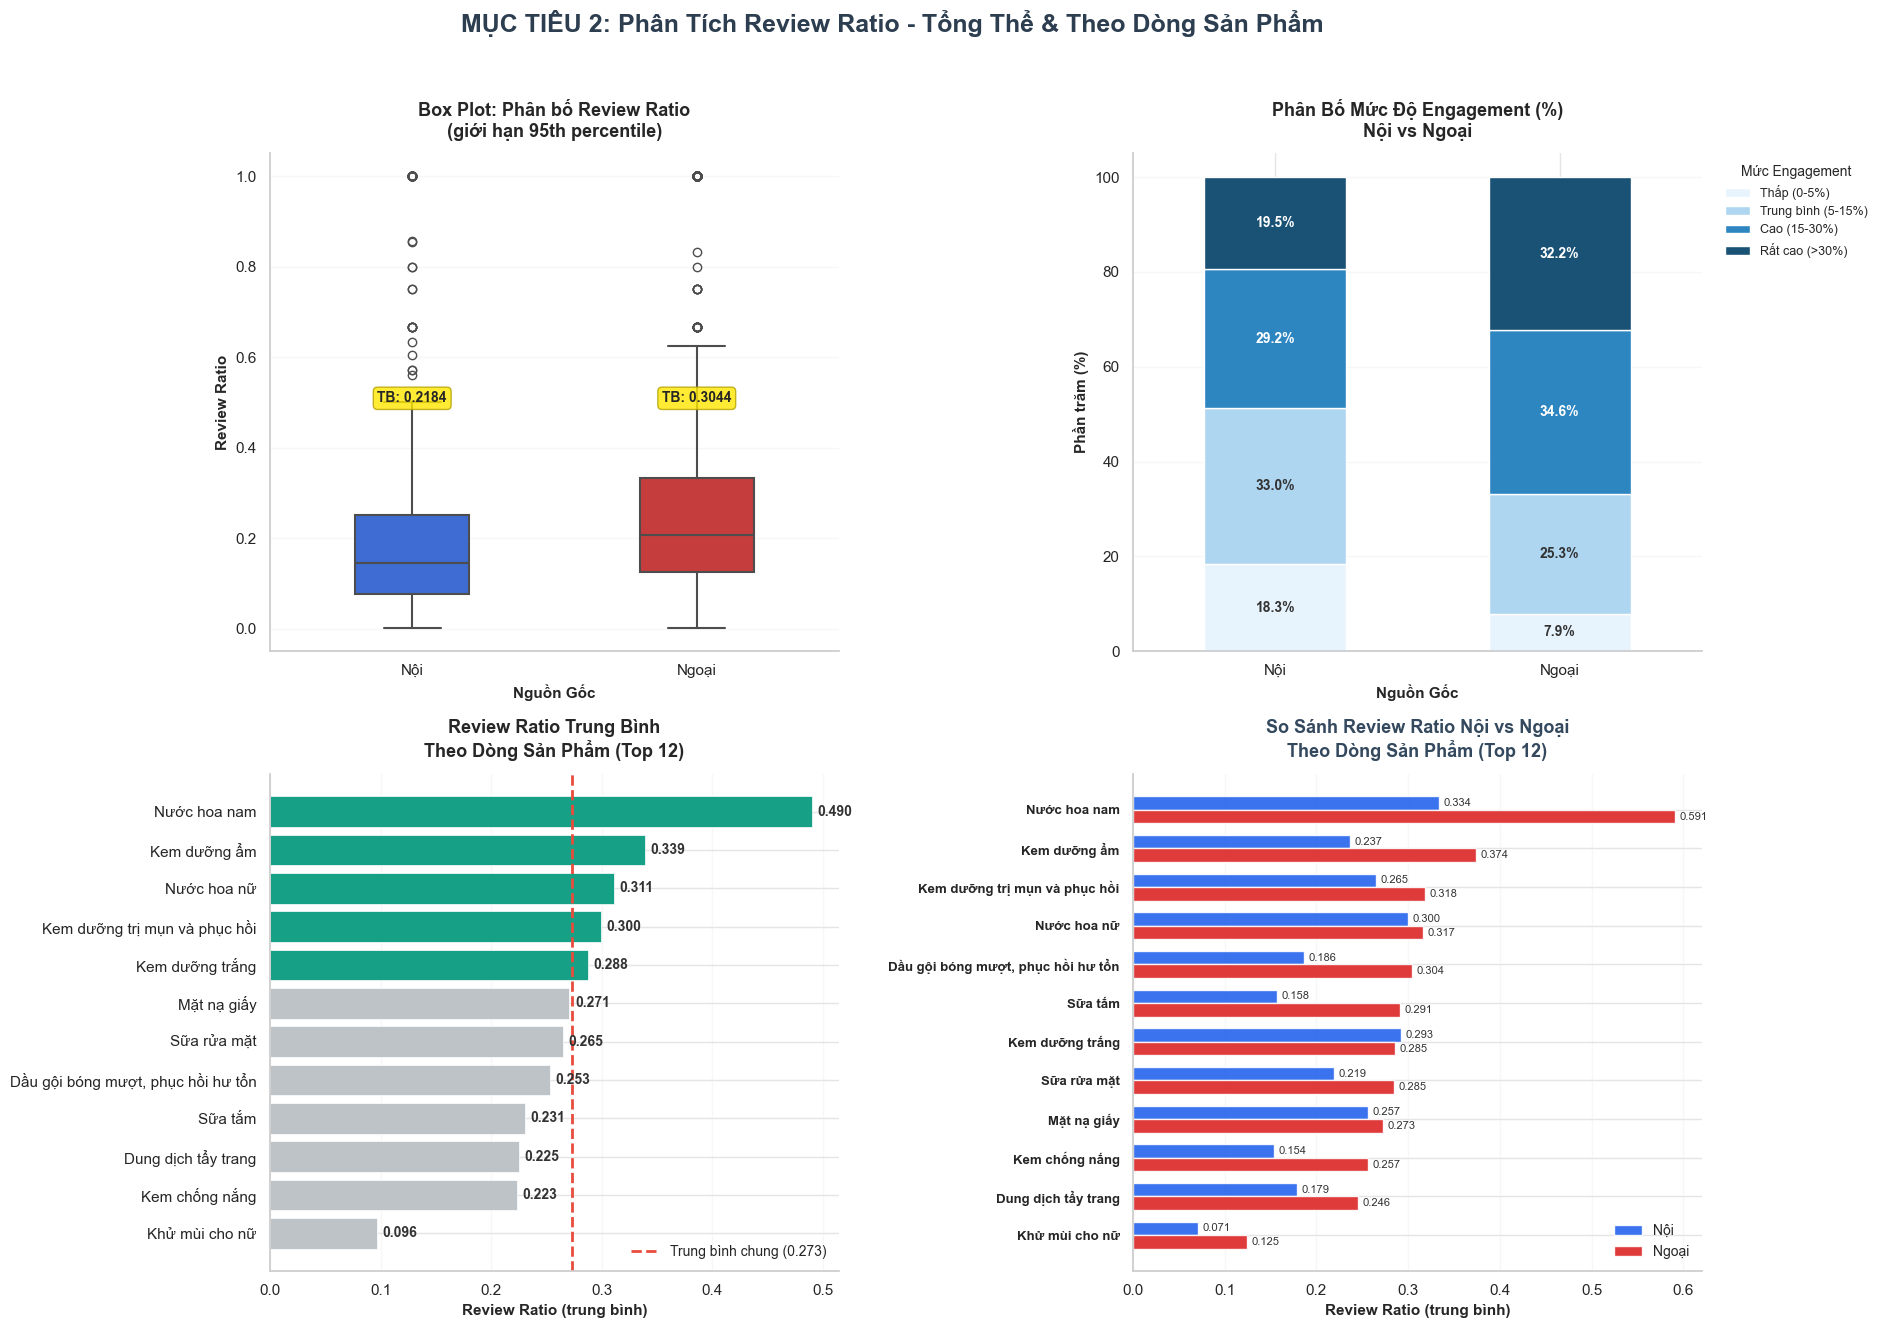

In [16]:
# Dải màu tuần tự cho Mức độ Engagement (Dùng dải màu Đỏ bạn thích, hoặc dải Xanh hiện tại của bạn)
# Ở đây mình giữ dải màu Xanh của bạn nhưng sắp xếp lại từ Nhạt -> Đậm cho đúng UX
# Lọc dữ liệu: review_ratio > 0 (chỉ sản phẩm có review)
df_review = df[df['review_ratio'] > 0].copy()

# Tính thống kê theo Nội/Ngoại
review_noi = df_review[df_review['origin_group'] == 'Nội']['review_ratio']
review_ngoai = df_review[df_review['origin_group'] == 'Ngoại']['review_ratio']

# Phân loại review ratio
df_review['review_engagement_level'] = pd.cut(
    df_review['review_ratio'],
    bins=[0, 0.05, 0.15, 0.3, float('inf')],
    labels=['Thấp (0-5%)', 'Trung bình (5-15%)', 'Cao (15-30%)', 'Rất cao (>30%)']
)

# ---- Thống kê theo từng dòng sản phẩm ----
TOP_N = 12
top_cats = (df_review.groupby('primary_category')['review_ratio']
            .count().sort_values(ascending=False).head(TOP_N).index.tolist())

df_top = df_review[df_review['primary_category'].isin(top_cats)].copy()

# Review Ratio trung bình theo category (tổng)
cat_mean = (df_top.groupby('primary_category')['review_ratio']
            .mean().sort_values(ascending=False))

# Review Ratio trung bình theo category x origin_group
cat_pivot = (df_top.groupby(['primary_category', 'origin_group'])['review_ratio']
             .mean().unstack().reindex(cat_mean.index))

# Tạo figure với multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('MỤC TIÊU 2: Phân Tích Review Ratio - Tổng Thể & Theo Dòng Sản Phẩm',
             fontsize=18, fontweight='bold', color='#2C3E50', y=1.02)

# ── Biểu đồ 1: Box Plot Nội vs Ngoại (95th pct) ──────────────────────────
ax1 = axes[0, 0]
df_review_lim = df_review[df_review['review_ratio'] <= df_review['review_ratio'].quantile(0.95)].copy()

sns.boxplot(data=df_review_lim, x='origin_group', y='review_ratio', ax=ax1,
            palette=my_palette, order=order_list, width=0.4, linewidth=1.5)

ax1.set_title('Box Plot: Phân bố Review Ratio\n(giới hạn 95th percentile)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Nguồn Gốc', fontsize=11, fontweight='bold')
ax1.set_ylabel('Review Ratio', fontsize=11, fontweight='bold')

for i, origin in enumerate(order_list):
    mean_val = df_review[df_review['origin_group'] == origin]['review_ratio'].mean()
    # Nhãn trung bình nền vàng
    ax1.text(i, df_review_lim['review_ratio'].quantile(0.90),
             f'TB: {mean_val:.4f}', ha='center', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#FFE600', edgecolor='#B3A100', alpha=0.8))
ax1.grid(axis='y', alpha=0.3)

# ── Biểu đồ 2: Stacked Bar - Engagement level Nội vs Ngoại ───────────────
ax2 = axes[0, 1]
engagement_by_origin = pd.crosstab(df_review['origin_group'], df_review['review_engagement_level'])

# Ép lại thứ tự Nội trước - Ngoại sau
engagement_by_origin = engagement_by_origin.reindex(order_list)
engagement_pct = engagement_by_origin.div(engagement_by_origin.sum(axis=1), axis=0) * 100

engagement_pct.plot(
    kind='bar', stacked=True, ax=ax2,
    color=seq_palette, edgecolor='white', linewidth=1
)
ax2.set_title('Phân Bố Mức Độ Engagement (%)\nNội vs Ngoại', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Nguồn Gốc', fontsize=11, fontweight='bold')
ax2.set_ylabel('Phần trăm (%)', fontsize=11, fontweight='bold')
ax2.legend(title='Mức Engagement', fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax2.tick_params(axis='x', rotation=0)

for i, container in enumerate(ax2.containers):
    # Chỉ hiện % nếu lớn hơn 5% để tránh chữ bị đè, text màu tùy theo độ đậm của nền
    text_color = 'white' if i >= 2 else '#333333'
    labels = [f'{v:.1f}%' if v >= 5 else '' for v in container.datavalues]
    ax2.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold', color=text_color)
ax2.grid(axis='y', alpha=0.3)

# ── Biểu đồ 3: Horizontal Bar - Review Ratio by Category (overall) ────────
ax3 = axes[1, 0]
cat_overall = df_top.groupby('primary_category')['review_ratio'].mean().sort_values(ascending=True)
overall_mean = df_review['review_ratio'].mean()

# UI/UX Logic: Vì là dữ liệu tổng hợp (không phân biệt Nội/Ngoại), ta dùng Xám cho Dưới TB, Xanh Ngọc cho Trên TB
colors3 = ['#16A085' if v >= overall_mean else '#BDC3C7' for v in cat_overall.values]

bars = ax3.barh(cat_overall.index, cat_overall.values, color=colors3, edgecolor='white', linewidth=0.5)
ax3.axvline(overall_mean, color='#E74C3C', linestyle='--',
            linewidth=2, label=f'Trung bình chung ({overall_mean:.3f})')

ax3.set_title('Review Ratio Trung Bình\nTheo Dòng Sản Phẩm (Top 12)', fontsize=13, fontweight='bold', pad=12)
ax3.set_xlabel('Review Ratio (trung bình)', fontsize=11, fontweight='bold')

for bar, val in zip(bars, cat_overall.values):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold', color='#333333')
ax3.legend(fontsize=10, frameon=False, loc='lower right')
ax3.grid(axis='x', alpha=0.3)

# ── Biểu đồ 4: Horizontal Grouped Bar ────────────────────────────────────
ax4 = axes[1, 1]

# Sắp xếp theo giá trị Ngoại giảm dần (giống cũ)
cat_order_h     = cat_pivot['Ngoại'].sort_values(ascending=True).index   # ascending=True vì barh đảo ngược
cat_pivot_h     = cat_pivot.reindex(cat_order_h)

noi_vals   = cat_pivot_h['Nội'].fillna(0).values
ngoai_vals = cat_pivot_h['Ngoại'].fillna(0).values
y_pos = np.arange(len(cat_order_h))
h = 0.35   # chiều cao mỗi thanh

b1 = ax4.barh(y_pos + h/2, noi_vals,   h, label='Nội',   color=C_DOMESTIC, alpha=0.9, edgecolor='white')
b2 = ax4.barh(y_pos - h/2, ngoai_vals, h, label='Ngoại', color=C_IMPORT,   alpha=0.9, edgecolor='white')

ax4.set_yticks(y_pos)
ax4.set_yticklabels(cat_order_h, fontsize=9.5, fontweight='bold')
ax4.set_xlabel('Review Ratio (trung bình)', fontsize=11, fontweight='bold')
ax4.set_title('So Sánh Review Ratio Nội vs Ngoại\nTheo Dòng Sản Phẩm (Top 12)',
              fontsize=13, fontweight='bold', pad=12, color='#34495E')
ax4.legend(fontsize=10, frameon=False)
ax4.grid(axis='x', alpha=0.3)

# Nhãn giá trị cuối mỗi thanh
for bar, val in zip(b1, noi_vals):
    if val > 0:
        ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8, color='#333333')
for bar, val in zip(b2, ngoai_vals):
    if val > 0:
        ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.subplots_adjust(right=0.95) # Chừa khoảng trống cho Legend của Biểu đồ 2
plt.savefig('objective2_review_ratio_categories.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### **2.2.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

① **Mức độ tương tác tổng quát (Biểu đồ 1 — Box Plot):** Hàng Ngoại có Review Ratio trung bình cao hơn rõ rệt (0.3044 vs 0.2184) - tức là cứ 100 lượt mua hàng Ngoại thì có ~30 khách để lại review, trong khi con số này chỉ là ~22 đối với hàng Nội. Hơn thế nữa, khi quan sát hộp tứ phân vị (khoảng Q1-Q3 chứa 50% dữ liệu cốt lõi), hộp của hàng Ngoại không chỉ trải rộng hơn mà đường Trung vị (Median) cũng nằm ở mức cao hơn hẳn (~0.2 so với ~0.15 của hàng Nội). Điều này cho thấy sự phân tán và mặt bằng chung về mức độ tương tác của hàng Ngoại là áp đảo.

② **Phân bố mức độ Engagement (Biểu đồ 2 — Stacked Bar):** Hàng Ngoại sở hữu tỷ lệ Engagement mức độ tốt (>15%) lên đến 66.8%, áp đảo hoàn toàn so với hàng Nội (48.7%). Đáng báo động nhất là ở phân khúc tương tác "Thấp" (0-5%), tỷ lệ của hàng Nội (18.3%) cao hơn gấp đôi so với hàng Ngoại (7.9%). Điều này cho thấy khách mua hàng Ngoại có nhiều động lực hơn để chia sẻ trải nghiệm — có thể do giá cao hơn nên cẩn thận đánh giá hơn hoặc tâm lý muốn chia sẻ trải nghiệm mua sắm quốc tế của họ.

③ **Review Ratio trung bình theo dòng sản phẩm (Biểu đồ 3 — Horizontal Bar):** Nước hoa nam dẫn đầu tuyệt đối với review ratio trung bình ~0.49 — gần gấp đôi mức trung bình chung. Nước hoa nữ và Kem dưỡng ẩm cũng nằm trong top cao. Ngược lại, Khử mùi cho nữ có mức engagement thấp nhất dù là dòng phổ biến — cho thấy đây là mặt hàng tiêu dùng thói quen, ít khiến khách hàng cảm thấy cần chia sẻ.

④ **So sánh Review Ratio Nội và Ngoại theo dòng sản phẩm (Biểu đồ 4 — Grouped Bar):** Hàng Ngoại dẫn trước ở hầu hết các dòng, đặc biệt rõ ở **Nước hoa nam** (0.5908 vs 0.3335) và **Kem dưỡng ẩm** (0.3742 vs 0.2368). Tuy nhiên, **Kem dưỡng trắng** là ngoại lệ đáng chú ý: hàng Nội thậm chí nhỉnh hơn (0.2926 vs 0.2852) — phản ánh sự gắn kết tốt của cộng đồng với sản phẩm dưỡng trắng nội địa. Điều này chứng tỏ "lợi thế bản địa". Các thương hiệu quốc nội thấu hiểu sâu sắc insight và chuẩn mực thẩm mỹ của người Việt, từ đó xây dựng thành công một hệ sinh thái người dùng trung thành có hệ số gắn kết vượt trội.

**Kết luận:** Hàng Ngoại có mức độ tương tác cộng đồng cao hơn nhìn chung, nhưng khoảng cách không đồng đều giữa các dòng sản phẩm. Nước hoa (cả nam và nữ) là dòng có engagement cao nhất, trong khi các sản phẩm chăm sóc hàng ngày như khử mùi, sữa tắm lại thấp hơn nhiều. Hàng Nội cần tập trung kích thích khách hàng để lại review đặc biệt ở các dòng skincare chủ lực (kem dưỡng, kem chống nắng, sữa rửa mặt) — nơi mức chênh lệch engagement với hàng Ngoại còn lớn và có tiềm năng cải thiện rõ nhất.

## **2.3. Mục tiêu 3:** Nhận diện phân khúc "Thất vọng" (Rating < 3.5) để chỉ ra các yếu tố khiến khách hàng chưa hài lòng ở hàng nội so với hàng ngoại.
### **2.3.1. Lí do chọn mục tiêu**

Việc nhận diện phân khúc "Thất vọng" (Rating < 3.5) được lựa chọn nhằm khoanh vùng nhanh chóng các lỗ hổng về chất lượng sản phẩm. Thông qua việc đối chiếu trực tiếp các yếu tố gây không hài lòng giữa hàng nội và hàng ngoại, phân tích này giúp các nhà bán hàng trong nước xác định chính xác điểm yếu cần khắc phục để nâng cao năng lực cạnh tranh. Đồng thời, việc giám sát nhóm đánh giá thấp còn đóng vai trò như một hệ thống cảnh báo sớm, giúp dự báo rủi ro đào thải sản phẩm, phát hiện kịp thời các trường hợp gian lận, hàng giả và bảo vệ quyết định mua sắm của người tiêu dùng

### **2.3.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:**

**Biểu đồ lựa chọn:**

* **Donut Chart đôi (Biểu đồ 1 & 2):** Trực quan hóa tỷ trọng sản phẩm "Thất vọng" (Rating < 3.5) trên tổng dung lượng sản phẩm của từng nhóm. Thiết kế Donut (vòng khuyết) kết hợp hiệu ứng explode giúp điều hướng thị giác tập trung ngay vào phần dữ liệu cảnh báo (màu Xanh/Đỏ). Cách bố trí này cho phép so sánh nhanh rủi ro tương đối (%) giữa hàng Nội và Ngoại mà không bị nhiễu bởi sự chênh lệch về số lượng mẫu tuyệt đối.
* **Histogram (Biểu đồ 3 - Phân bố Rating):** hắc họa mật độ phân phối điểm số trong vùng thấp. Bằng cách để các cột dữ liệu sát nhau, biểu đồ thể hiện sự liên tục của biến số Rating, cho phép quan sát hình dáng phân phối (distribution shape) để xác định xem sự thất vọng tập trung ở ngưỡng cận biên (3.0) hay rớt thẳng xuống các mốc "điểm liệt" cực đoan (1.0).
* **Grouped Bar Chart theo khoảng giá (Biểu đồ 4):** Thể hiện phân bố sản phẩm thất vọng trên từng phân khúc giá của cả hai nhóm, giúp xác định phân khúc giá nào tập trung nhiều sản phẩm kém chất lượng nhất — từ đó gợi ý định hướng cải thiện ưu tiên.

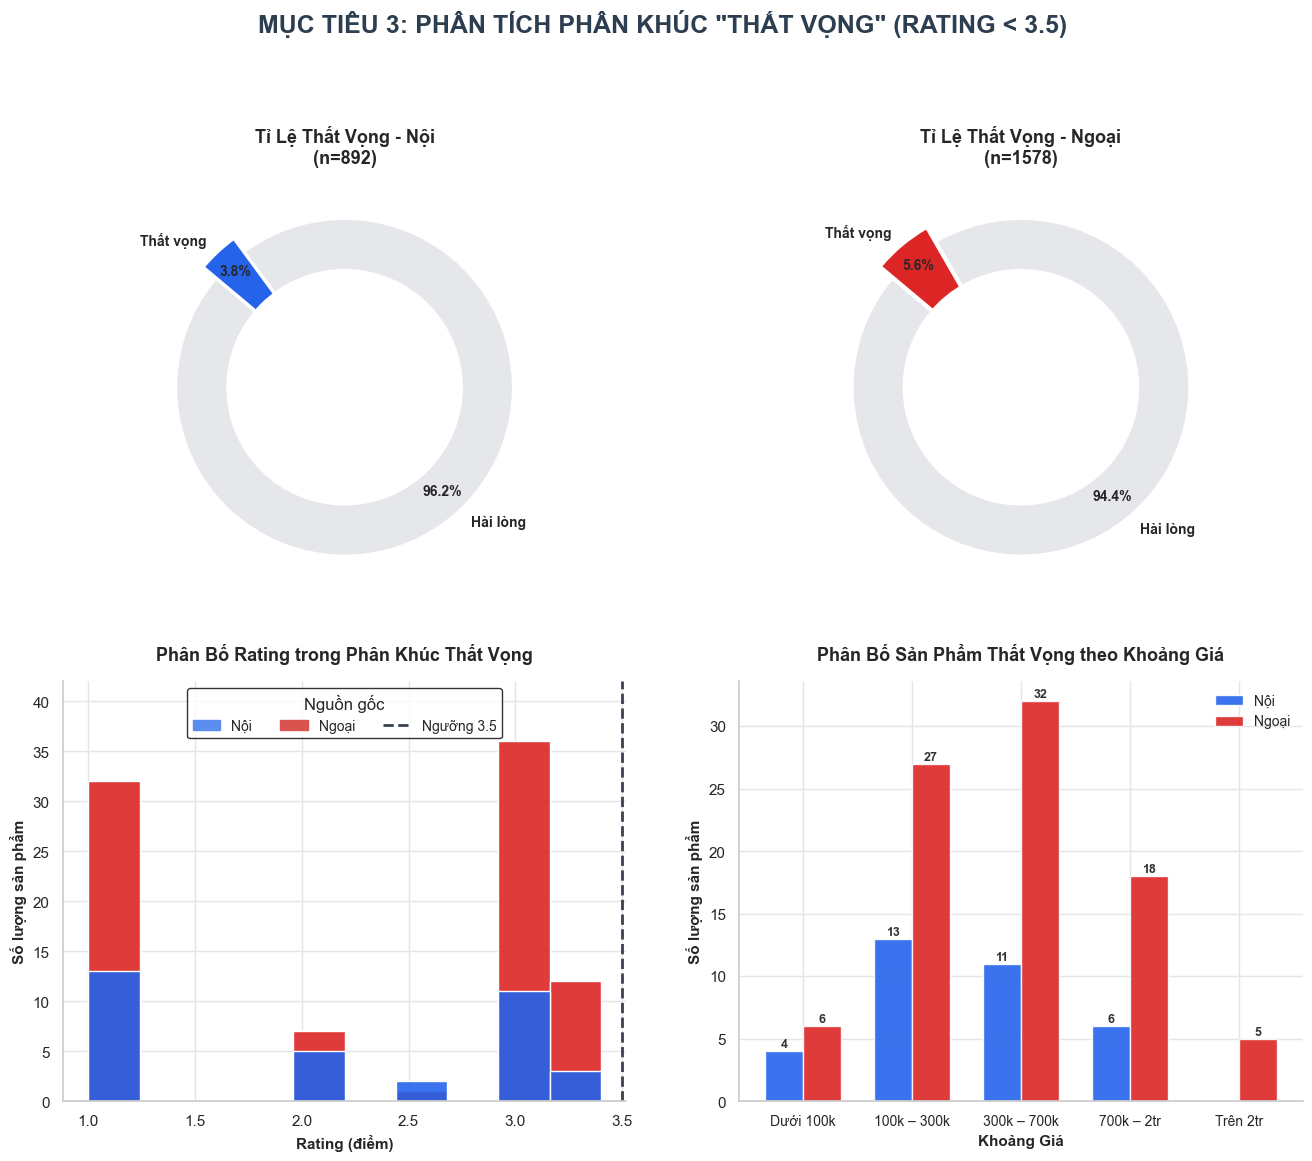

In [24]:
# Lọc dữ liệu: rating < 3.5 và rating > 0 (sản phẩm không hài lòng)
df_dissatisfied = df[(df['rating'] > 0) & (df['rating'] < 3.5)].copy()
df_all_rated = df[df['rating'] > 0].copy()

# Thống kê chi tiết
dissatisfied_noi = df_dissatisfied[df_dissatisfied['origin_group'] == 'Nội']
dissatisfied_ngoai = df_dissatisfied[df_dissatisfied['origin_group'] == 'Ngoại']

# Palette cho khoảng giá (Sequential - từ nhạt đến đậm để dễ nhìn)
price_palette = ['#FEE2E2', '#FCA5A5', '#EF4444', '#B91C1C', '#7F1D1D']


# Tạo figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('MỤC TIÊU 3: PHÂN TÍCH PHÂN KHÚC "THẤT VỌNG" (RATING < 3.5)', 
             fontsize=18, fontweight='bold', color='#2C3E50', y=1.02)

# BIỂU ĐỒ 1 & 2: Donut Charts - Tỉ lệ thất vọng

for i, origin in enumerate(order_list):
    ax = axes[0, i]
    total = len(df_all_rated[df_all_rated['origin_group'] == origin])
    dissatisfied_count = len(df_dissatisfied[df_dissatisfied['origin_group'] == origin])
    satisfied_count = total - dissatisfied_count
    
    sizes = [satisfied_count, dissatisfied_count]
    # Màu xám cho hài lòng để "dìm" xuống, màu chủ đạo (Xanh/Đỏ) cho thất vọng để làm nổi bật
    colors = ['#E5E7EB', my_palette[origin]]
    
    # Vẽ Pie chart dạng Donut cho hiện đại
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=['Hài lòng', 'Thất vọng'],
        colors=colors, 
        autopct='%.1f%%', 
        startangle=140, 
        pctdistance=0.85,
        explode=(0, 0.1), # Đẩy phần thất vọng ra một chút để gây chú ý
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    
    # Vẽ vòng tròn trắng ở giữa tạo thành Donut chart
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    ax.add_artist(centre_circle)
    
    ax.set_title(f'Tỉ Lệ Thất Vọng - {origin}\n(n={total})', fontsize=13, fontweight='bold', pad=10)

# BIỂU ĐỒ 3

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Vẽ biểu đồ Histogram
ax3 = axes[1, 0]
sns.histplot(
    data=df_dissatisfied, x='rating', hue='origin_group', hue_order=order_list,
    ax=ax3, palette=my_palette, bins=10, alpha=0.9
)

ax3.set_title('Phân Bố Rating trong Phân Khúc Thất Vọng', fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel('Rating (điểm)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Số lượng sản phẩm', fontsize=11, fontweight='bold')

# Vẽ đường ngưỡng
ax3.axvline(x=3.5, color='#374151', linestyle='--', linewidth=2)

# --- TẠO CHÚ THÍCH THỦ CÔNG ---
# Lưu ý: Bạn có thể đổi mã màu hex (#...) cho khớp hoàn toàn với my_palette của bạn
patch_noi = mpatches.Patch(color='#5A8DEE', label='Nội')   # Màu Xanh
patch_ngoai = mpatches.Patch(color='#D9534F', label='Ngoại') # Màu Đỏ
line_nguong = mlines.Line2D([], [], color='#374151', linestyle='--', linewidth=2, label='Ngưỡng 3.5')

# Gắn chú thích vào biểu đồ
ax3.legend(
    handles=[patch_noi, patch_ngoai, line_nguong], 
    title='Nguồn gốc', 
    fontsize=10, 
    loc='upper center',  # Đưa ra giữa phía trên
    ncol=3,              # Dàn ngang thành 3 cột để không chiếm diện tích dọc
    frameon=True,
    edgecolor='black'
)

# (Mẹo phụ) Nới rộng trục Y một chút để có thêm "không gian thở" cho chú thích
# Hiện tại cột cao nhất của bạn khoảng 36, nới lên 42 là đẹp:
ax3.set_ylim(0, 42)

# BIỂU ĐỒ 4: Bar chart - Khoảng giá 
ax4 = axes[1, 1]

# Pivot lại: index = price_segment, columns = origin_group (Nội / Ngoại)
price_pivot = pd.crosstab(
    df_dissatisfied['price_segment'],
    df_dissatisfied['origin_group']
).reindex(price_order)   # đảm bảo thứ tự phân khúc giá đúng

# Các cột có thể thiếu (hàng Nội không có sản phẩm ở "Trên 2tr") → fillna
if 'Nội'   not in price_pivot.columns: price_pivot['Nội']   = 0
if 'Ngoại' not in price_pivot.columns: price_pivot['Ngoại'] = 0
price_pivot = price_pivot[['Nội', 'Ngoại']].fillna(0)

x   = np.arange(len(price_pivot))
w   = 0.35
b1  = ax4.bar(x - w/2, price_pivot['Nội'],   w, label='Nội',   color=C_DOMESTIC, alpha=0.9, edgecolor='white')
b2  = ax4.bar(x + w/2, price_pivot['Ngoại'], w, label='Ngoại', color=C_IMPORT,   alpha=0.9, edgecolor='white')

ax4.set_title('Phân Bố Sản Phẩm Thất Vọng theo Khoảng Giá',
              fontsize=13, fontweight='bold', pad=15)
ax4.set_xlabel('Khoảng Giá', fontsize=11, fontweight='bold')
ax4.set_ylabel('Số lượng sản phẩm', fontsize=11, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(price_pivot.index, rotation=0, ha='center', fontsize=10)
ax4.legend(fontsize=10, frameon=False)

# Nhãn số trên đầu cột (ẩn nếu = 0
for bar in b1:
    v = bar.get_height()
    if v > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 str(int(v)), ha='center', fontsize=9, fontweight='bold', color='#333333')
for bar in b2:
    v = bar.get_height()
    if v > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 str(int(v)), ha='center', fontsize=9, fontweight='bold', color='#333333')



### **2.3.3. Nhận xét và kết luận**

**Nhận xét từ biểu đồ:**

① **Tỉ lệ Thất vọng tổng quát (Biểu đồ 1 & 2 — Donut Chart đôi):** Dữ liệu bộc lộ một nghịch lý thú vị: hàng Ngoại lại ghi nhận tỷ lệ sản phẩm rơi vào nhóm "thất vọng" cao hơn hàng Nội (5.6% vs 3.8%). Sự chênh lệch 1.8% điểm phần trăm có thể liên quan đến giá cao hơn dẫn đến kỳ vọng khắt khe hơn, khiến khả năng thất vọng cao hơn khi sản phẩm không đáp ứng.

② **Mức độ nghiêm trọng của thất vọng (Biểu đồ 3 — Histogram):** Dù hàng Nội có tỷ lệ lỗi thấp hơn, nhưng biểu đồ Histogram cho thấy mật độ điểm của hàng Nội lại tập trung sâu hơn ở các mức 1.0 - 2.0. Đây là dấu hiệu của sự thất bại toàn diện về chất lượng (như hàng giả, gây kích ứng da nghiêm trọng), trái ngược với hàng Ngoại thường tập trung ở mức 3.0 (có thể chỉ là không hợp màu sắc hoặc mùi hương).

③ **Tác động thực tế lên thị trường (phân tích Sold Count):** Sản phẩm Nội thất vọng có lượt bán trung bình **161 lượt** — cao hơn rất nhiều so với hàng Ngoại tệ (**14 lượt**). Điều này có nghĩa là một số sản phẩm nội kém chất lượng nhưng vẫn được mua với số lượng lớn — có thể do giá rẻ hoặc thiếu thông tin — gây thiệt hại thực tế cho người tiêu dùng.

④ **Phân bố theo khoảng giá (Biểu đồ 4 — Grouped Bar):** Sản phẩm Ngoại thất vọng tập trung nhiều nhất ở phân khúc **300k – 700k** (32 sản phẩm) — phân khúc tầm trung cao nơi kỳ vọng lớn nhất. Hàng Nội thất vọng tập trung ở **100k – 300k** (13 sản phẩm), phân khúc đại trà. Đặc biệt, hàng Nội không có sản phẩm thất vọng nào ở phân khúc **Trên 2tr**, phản ánh hàng Nội vốn không hiện diện ở phân khúc cao cấp.

**Kết luận:** Phân khúc thất vọng của hàng Ngoại nhiều hơn về tỉ lệ, nhưng vấn đề của hàng Nội nghiêm trọng hơn về tác động thực tế: các sản phẩm nội tệ vẫn được bán với số lượng lớn (trung bình 161 lượt/sản phẩm) mà không có cơ chế lọc hiệu quả. Tiki nên tăng cường cơ chế kiểm soát chất lượng và cảnh báo sớm (early warning) dựa trên chỉ số rating để bảo vệ người tiêu dùng khỏi các sản phẩm nội kém chất lượng nhưng vẫn đang bán tốt.
